## Data: Online Retail II

This Online Retail II data set contains all the transactions occurring for a UK-based and registered, non-store online retail between 01/12/2009 and 09/12/2011.The company mainly sells unique all-occasion gift-ware. Many customers of the company are wholesalers.

The dataset can be accessed at the following link: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci/

Attribute Information:

- InvoiceNo: Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'c', it indicates a cancellation.
- StockCode: Product (item) code. Nominal. A 5-digit integral number uniquely assigned to each distinct product.
- Description: Product (item) name. Nominal.
- Quantity: The quantities of each product (item) per transaction. Numeric.
- InvoiceDate: Invice date and time. Numeric. The day and time when a transaction was generated.
- UnitPrice: Unit price. Numeric. Product price per unit in sterling (Â£).
- CustomerID: Customer number. Nominal. A 5-digit integral number uniquely assigned to each customer.
- Country: Country name. Nominal. The name of the country where a customer resides.

## Business Goals

Market Basket Analysis is a data mining technique employed to discover relationships and patterns within large datasets, particularly in the context of market analysis. By identifying frequently co-occurring items in transactions, businesses can gain valuable insights into customer behavior, optimize product placement, and enhance overall marketing strategies.

## Objectives

1. **Association Rule Discovery**:
    Identify associations and correlations among products or items in a dataset. Discover rules that indicate the likelihood of certain items being bought together.
2. **Cross-Selling Opportunities**:
    Uncover opportunities for cross-selling by understanding which products are frequently purchased together.
4. **Optimizing Product Layout**:
    Arrange products in-store or online in a way that encourages the purchase of related items, creating a more convenient and satisfying shopping experience.

## Methods

### Apriori algorithm 

- We utilize the Apriori algorithm for conducting market basket analysis.
- This algorithm proves highly effective in discerning frequent itemsets and deriving association rules, relying on predefined metrics like support and confidence.
- To execute the Apriori algorithm, we utilize the mlxtend library, a reliable Python library for machine learning extensions.

### Key Metrics

- **Support** 
    - Support measures how frequently an association rule happens in a dataset.
- **Confidence** 
    - Confidence measures how strong an association rule is. 
    - That is to say, in market basket analysis terms, how likely is a second product to be present in the basket if the first is.
    - Confidence(A→B) = Support(A∪B)/Support(A)×100%
    - Confidence(B→A) = Support(A∪B)/Support(B)×100%
- **Lift**
    - Lift measures how much more likely two items are to be bought together compared to being bought individually at random.
    - Lift(A→B)= Support(A∪B)/Support(A)×Support(B)
    - If Lift = 1, it means there is no association between A and B.
    - If Lift > 1, it indicates that A and B are more likely to be bought together than randomly.
    - If Lift < 1, it suggests that A and B are less likely to be bought together than randomly.
- **Leverage**
    - Leverage measures the difference between the observed frequency of A and B occurring together and the frequency that would be expected if A and B were statistically independent.
    - Leverage(A→B)=Support(A∪B)−(Support(A)×Support(B))
    - Positive leverage indicates that the items appear together more frequently than expected by chance.
    - Zero leverage means the items occur together exactly as expected based on their individual supports.
    - Negative leverage implies the items co-occur less frequently than expected.
    
- **Conviction**
    - Conviction measures the ratio of the expected frequency that A occurs without B to the frequency that A occurs when B is present.
    - Conviction(A→B)= 1−Support(B)/1−Confidence(A→B)
    - Conviction(B→A)= 1−Support(A)/1−Confidence(B→A)
    - If Conviction = 1, it means that A and B are independent of each other.
    - If Conviction > 1, it suggests that the presence of B has increased the likelihood of A, indicating a strong association.
    - If Conviction < 1, it indicates a negative association between A and B.
- **Zhang’s metric**
    - Measure that looks not only at positive associations, but also negative. It can says, for instances, if buying A makes someone NOT buy B.
    - Value: < 0 if there’s a negative association (dissociation), > 0 if there’s a positive association where -1 and 1 are the extreme values.

## Environment Setup

In [1]:
# ◯ Paso 1: Importar bibliotecas del sistema operativo y expresiones regulares
import os                    # permite interactuar con el sistema de archivos (por ejemplo, para leer rutas, archivos, etc.)
import re                    # módulo para trabajar con expresiones regulares, útil para búsquedas o limpiezas complejas de texto
import sys                   # Permite manipular el entorno de ejecución de Python (paths, argumentos, etc.)

# ✓ Agregar la ruta al directorio raíz del proyecto para que se puedan importar módulos personalizados (como 'networks')
sys.path.append(os.path.abspath(".."))      # Esto le indica a Python que también busque módulos en el directorio raíz de tu proyecto.

# ◯ Paso 2: Importar bibliotecas de análisis de datos

import pandas as pd          # manipulación de estructuras de datos (DataFrames)
import numpy as np           # operaciones matemáticas eficientes con matrices y vectores

# ◯ Paso 3: Importar bibliotecas de visualización
import plotly.express as px  # librería interactiva para gráficos (barras, dispersión, líneas, etc.)
import networkx as nx        # usada para construir y visualizar grafos (ideal para reglas de asociación o redes de productos)

# ◯ Paso 4: Importar utilidades para manejar datos complejos
import json                 # permite cargar y guardar datos en formato JSON (muy útil para configuración o exportación)
import copy                 # permite realizar copias profundas de estructuras de datos complejas (para evitar modificaciones indeseadas)

In [2]:
# ◯ Paso 5: Importar módulos del paquete mlxtend para minería de patrones frecuentes

# ✓ apriori:
#   - Algoritmo que permite identificar conjuntos de ítems frecuentes en transacciones.
#   - Se basa en el soporte mínimo para filtrar combinaciones relevantes.
from mlxtend.frequent_patterns import apriori

# ✓ association_rules:
#   - Genera reglas de asociación a partir de los ítems frecuentes.
#   - Calcula métricas como lift, confidence, support, leverage, conviction, etc.
from mlxtend.frequent_patterns import association_rules

# ✓ TransactionEncoder:
#   - Transforma listas de transacciones (lista de listas) en un formato de matriz binaria.
#   - Necesario para aplicar el algoritmo Apriori en formato correcto (DataFrame booleano).
from mlxtend.preprocessing import TransactionEncoder

In [3]:
# ◯ Paso 6: Importar clases personalizadas del proyecto para construir y visualizar redes de productos

# ✓ RulesGraphManager:
#   - Clase encargada de construir un grafo desde las reglas de asociación.
#   - Administra nodos, pesos y relaciones para visualización o análisis estructural.
from networks.RulesGraphManager import RulesGraphManager as RGM

# ✓ ProductNetwork:
#   - Construye una red de co-ocurrencia entre productos.
#   - Se puede usar para analizar centralidad, agrupaciones, o rutas entre ítems.
from networks.ProductNetwork import ProductNetwork

# ✓ CrossSellingProducts:
#   - Implementa lógica para detectar oportunidades de venta cruzada (cross-selling).
#   - Utiliza reglas de asociación y métricas de soporte/confianza para sugerencias comerciales.
from networks.CrossSellingProducts import CrossSellingProducts

In [4]:
# ◯ Paso 7: Importar módulos para agrupar nodos y construir clusters

# ✓ NxGrouper:
#   - Agrupa nodos de un grafo usando algoritmos de agrupamiento (community detection, modularidad, etc.).
#   - Ideal para resaltar grupos de productos que aparecen frecuentemente juntos.
from grouper.NxGrouper import NxGrouper


# ◯ Paso 8: Importar módulos para visualización en forma de tablas y mapas de calor

# ✓ HeatmapCrosstab:
#   - Genera un heatmap basado en una tabla cruzada de productos o métricas (por ejemplo, co-ocurrencia).
#   - Útil para mostrar la intensidad de relación entre productos de forma matricial.
from charts.HeatmapXTab import HeatmapCrosstab

In [36]:
# ◯ Paso 9: Importar módulos de visualización interactiva con ECharts (JS embebido en Jupyter o Streamlit)

# ✓ EgraphForce:
#   - Muestra grafos con layout de fuerzas (force-directed graph).
#   - Ideal para ver agrupamientos naturales en la red de productos.
from echarts.EgraphForce import EgraphForce

# ✓ EgraphStandard:
#   - Visualización de grafos más clásica (sin fuerzas), útil para control de diseño más rígido.
from echarts.EgraphStandard import EgraphStandard

# ✓ JupyterEcharts:
#   - Motor para renderizar visualizaciones ECharts dentro de notebooks Jupyter.
#   - Se usa como puente para mostrar gráficos de tipo `EgraphForce` o `EgraphStandard`.
from echarts.JupyterEcharts import JupyterEcharts

In [6]:
# ◯ Paso 10: Configurar la visualización de DataFrames en Pandas

# ✓ Mostrar hasta 100 filas cuando se imprime un DataFrame
#   - Por defecto Pandas muestra solo 10 o 20.
#   - Esto permite ver más resultados directamente sin truncamiento.
pd.set_option('display.max_rows', 100)

# ✓ Mostrar el contenido completo de las celdas (sin cortar con "...")
#   - Es útil cuando las columnas contienen textos largos o listas.
#   - 'None' desactiva el límite de caracteres por columna.
pd.set_option('display.max_colwidth', None)


pd.set_option('display.float_format', '{:.4f}'.format)

## Data Preparation

### Load Dataset

In [7]:
# ◯ Paso 11: Construir la ruta al archivo CSV

# ✓ Combina de forma segura las partes de una ruta de archivo (compatible con diferentes sistemas operativos)
#   - En este caso: "F:\Data\datas" + "online_retail_II.csv"
#   - Devuelve una ruta completa: "F:\Data\datas\online_retail_II.csv"
base_dir = '/workspaces/Final_Project_MBA'
pathname = os.path.join(base_dir, "data/raw", "online_retail_II.csv")
print(pathname)

# ◯ Paso 12: Cargar los datos desde el archivo CSV

# ✓ Lee el archivo CSV ubicado en la ruta 'pathname'
# ✓ Solo carga las columnas 'Invoice' y 'Description' para reducir memoria y enfocar el análisis
#   - 'Invoice': identificador de cada transacción
#   - 'Description': nombre del producto comprado
df = pd.read_csv(pathname, usecols=['Invoice', 'Description'])


/workspaces/Final_Project_MBA/data/raw/online_retail_II.csv


In [8]:
df.shape

(1067371, 2)

### Data Cleaning

#### Drop missing values

In [9]:
# ◯ Paso 13: Verificar valores nulos (NaN) en el DataFrame

# ✓ df.isna(): genera un DataFrame booleano con True donde hay valores nulos (NaN) y False en el resto
# ✓ .sum(): suma los True columna por columna, devolviendo la cantidad total de valores faltantes por columna
df.isna().sum()


Invoice           0
Description    4382
dtype: int64

In [10]:
# ◯ Paso 14: Eliminar filas que contienen valores nulos en cualquier columna

# ✓ dropna(): elimina todas las filas del DataFrame que tengan al menos un valor NaN (nulo)
# ✓ Al reasignar el resultado a 'df', actualizamos el DataFrame original con la versión limpia
df = df.dropna()
df.shape

(1062989, 2)

#### Trim space in description column

In [11]:
# ◯ Paso 15: Limpiar texto en la columna 'Description'

# ✓ .str.strip():
#   - Elimina espacios en blanco al inicio y al final de cada descripción de producto.
#   - Ejemplo: "  RED T-SHIRT  " → "RED T-SHIRT"
df['Description'] = df['Description'].str.strip()


# ✓ .replace(r'\s{2,}', ' ', regex=True):
#   - Reemplaza cualquier secuencia de 2 o más espacios internos por un solo espacio
#   - r'\s{2,}' es una expresión regular: busca espacios repetidos
#   - Esto ayuda a estandarizar nombres de productos como "RED    T-SHIRT" → "RED T-SHIRT"
df['Description'] = df['Description'].replace(r'\s{2,}', ' ', regex=True)

#### Drop duplicate rows

There are two possible reasons for duplicate rows. 
1. The cashier might have scanned each product individually instead of scanning once and entering the quantity, resulting in multiple entries for each product on the invoice. 
2. The cashier might have accidentally scanned the same product twice. 

- **Decision process**: 
    - The first scenario is more common, so we assume that the duplicate rows are not mistakes.
    - But, since Apriori algorithm assumes that each item in each transaction is a binary occurrence, meaning it considers whether an item is present or not, but not the quantity of the item, so we decide to drop duplicate rows.
<br>
- **Action**: We drop duplicate rows

In [12]:
# ◯ Paso 16: Contar la cantidad de filas duplicadas en el DataFrame

# ✓ df.duplicated():
#   - Devuelve una Serie booleana: True si la fila está duplicada (misma combinación de valores en todas las columnas)
#   - Por defecto compara todas las columnas

# ✓ df.loc[...]: selecciona solo las filas que están duplicadas

# ✓ .shape: devuelve una tupla con (número de filas, número de columnas)
#   - Al usarlo sobre df.loc[duplicated()], obtenemos cuántas filas están duplicadas

df.loc[df.duplicated()].shape

(46678, 2)

In [13]:
# ◯ Paso 17: Eliminar filas duplicadas del DataFrame

df = df.drop_duplicates()

In [14]:
df.shape

(1016311, 2)

#### Drop cancelation invoice rows

In [15]:
# ◯ Paso 18: Contar filas correspondientes a facturas canceladas

# ✓ df['Invoice'].str.startswith('C'):
#   - Verifica si el valor en la columna 'Invoice' comienza con la letra 'C'
#   - Devuelve una Serie booleana: True si la factura es de tipo cancelación

# ✓ df[...]:
#   - Filtra el DataFrame y devuelve solo las filas con facturas canceladas

# ✓ .shape:
#   - Devuelve una tupla con (número de filas, número de columnas)
#   - Sirve para contar cuántas filas corresponden a cancelaciones

df[df['Invoice'].str.startswith('C')].shape

(18901, 2)

In [16]:
# ◯ Paso 19: Eliminar facturas canceladas del DataFrame

#   - El operador ~ invierte los booleanos: deja solo las facturas que **no** son canceladas

df = df[~df['Invoice'].str.startswith('C')]

In [17]:
df.shape

(997410, 2)

### Data Encoding

Empezamos a preparar el dataset para convertirlo en formato transaccional — paso previo al uso de TransactionEncoder.  
¿Por qué convertir en listas?

Porque en el siguiente paso vas a agrupar por Invoice y sumar las listas de productos por factura:

transactions = dfs.groupby('Invoice')['Description'].sum().tolist()

Esto te da una estructura como:
[
  ['TOY CAR', 'BALL', 'BAG'],
  ['RIBBON', 'CANDLE'],
  ...
]

[
  ['TOY CAR', 'BALL', 'BAG'],
  ['RIBBON', 'CANDLE'],
  ...
]

La cual es ideal para usar con TransactionEncoder.

In [18]:
# ◯ Paso 20: Crear una copia del DataFrame y transformar la columna 'Description' en listas

# ✓ df.copy():
#   - Se crea una copia completa del DataFrame original para trabajar sin modificar el original directamente
dfs = df.copy()

# ✓ .transform(lambda x: [x]):
#   - Convierte cada valor de la columna 'Description' en una lista con un solo elemento
#   - Ejemplo: "TOY CAR" → ["TOY CAR"]
#   - Esto es útil para luego hacer un agrupamiento por factura y concatenar listas de productos

dfs['Description'] = dfs['Description'].transform(lambda x: [x])
dfs

,Invoice,Description
0,489434,[15CM CHRISTMAS GLASS BALL 20 LIGHTS]
1,489434,[PINK CHERRY LIGHTS]
2,489434,[WHITE CHERRY LIGHTS]
3,489434,"[RECORD FRAME 7"" SINGLE SIZE]"
4,489434,[STRAWBERRY CERAMIC TRINKET BOX]
...,...,...
1067366,581587,[CHILDREN'S APRON DOLLY GIRL]
1067367,581587,[CHILDRENS CUTLERY DOLLY GIRL]
1067368,581587,[CHILDRENS CUTLERY CIRCUS PARADE]
1067369,581587,[BAKING SET 9 PIECE RETROSPOT]


In [19]:
# ◯ Paso 21: Agrupar productos por factura para construir las transacciones

# ✓ dfs.groupby('Invoice')['Description'].sum():
#   - Agrupa el DataFrame por la columna 'Invoice'
#   - Suma las listas de productos de cada factura (recordá que ya convertimos cada descripción en una lista en el paso anterior)
#   - Al sumar listas, se concatenan (por ejemplo: ['A'] + ['B'] → ['A', 'B'])
#   - Resultado: Serie donde cada fila es una factura, y su valor es una lista de productos comprados en esa factura


dfs = dfs.groupby('Invoice')['Description'].sum()  # usamos esto porque ya eliminamos duplicados antes
dfs

# dfs = dfs.groupby('Invoice')['Description'].sum().map(lambda x: list(set(x)))
    # Esta línea remueve productos repetidos dentro de la misma factura usando set(x).
    # Luego convierte de nuevo a lista para mantener el formato.
    # Esto es útil si querés que cada producto aparezca una sola vez por factura (sin repetir), pero 
    # puede alterar el soporte real si en el análisis te importa la cantidad de veces que se compró un ítem en la misma transacción.


# df.groupby('Invoice')['Description'].unique() # this code is slow
    # Esto también quita duplicados, pero usando unique() que devuelve un np.array de valores únicos por factura.
    # puede ser más lento en DataFrames grandes, especialmente si se usan muchos objetos.

Invoice
489434                                                                                                                                                                                                                                                                                                                                                                                                                                         [15CM CHRISTMAS GLASS BALL 20 LIGHTS, PINK CHERRY LIGHTS, WHITE CHERRY LIGHTS, RECORD FRAME 7" SINGLE SIZE, STRAWBERRY CERAMIC TRINKET BOX, PINK DOUGHNUT TRINKET POT, SAVE THE PLANET MUG, FANCY FONT HOME SWEET HOME DOORMAT]
489435                                                                                                                                                                                                                                                                                                                                           

In [20]:
# ◯ Paso 22: Preparar codificación binaria de transacciones para usar en Apriori

# ✓ Instanciamos un codificador de transacciones de mlxtend
#   - Este encoder convierte listas de productos por factura en una matriz booleana
#   - Cada columna será un producto, y cada fila representará una transacción
encoder = TransactionEncoder()

# ✓ Ajustamos el encoder al conjunto de transacciones 'dfs'
#   - .fit(dfs): detecta todos los productos únicos del dataset
#   - .transform(dfs): convierte cada transacción (lista de productos) en una fila de presencia/ausencia (True/False)
df_encoder = encoder.fit(dfs).transform(dfs)

In [21]:
# ◯ Paso 23: Visualizar las primeras 5 transacciones codificadas

# ✓ df_encoder[:5]:
#   - Muestra las primeras 5 filas del array codificado
#   - Cada fila representa una transacción
#   - Cada columna representa un producto
#   - El valor es booleano (True/False) indicando si el producto está presente en la transacción

df_encoder[:5]

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(5, 5628))

In [22]:
# ◯ Paso 24: Convertir la matriz booleana codificada a un DataFrame con nombres de productos

# ✓ df_encoder: matriz NumPy con True/False indicando si cada producto está presente en una transacción
# ✓ encoder.columns_: lista de nombres de los productos, en el mismo orden que las columnas de df_encoder

# ✓ Creamos un nuevo DataFrame llamado one_hot_transactions
#   - Cada fila es una transacción
#   - Cada columna es un producto
#   - True indica que el producto está presente en esa transacción


one_hot_transactions = pd.DataFrame(df_encoder, columns=encoder.columns_)

In [23]:
one_hot_transactions.head()

,*Boombox Ipod Classic,*USB Office Glitter Lamp,*USB Office Mirror Ball,10 COLOUR SPACEBOY PEN,11 PC CERAMIC TEA SET POLKADOT,12 ASS ZINC CHRISTMAS DECORATIONS,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,...,wrongly coded 20713,wrongly coded 23343,wrongly coded-23343,wrongly marked,wrongly marked 23343,wrongly marked carton 22804,wrongly marked. 23343 in box,wrongly sold (22719) barcode,wrongly sold as sets,wrongly sold sets
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Data Mining (Rules Extraction)

- The following parameters are configured for the algorithm:
    - Maximum Combination Length
        - We set the maximum combination length to 2 items.
        - This choice is made to focus on pairs of items, allowing for a more targeted analysis of co-occurrences.
    - Minimum Occurance Product
        - We set the minimum support threshold at 1% to focus on the most commonly purchased products
    - Minimum Co-Occurrence Support Threshold        
        - A minimum co-occurrence support threshold of 1% is established to filter out infrequent itemsets. 
        - This ensures that only associations with a significant presence in the dataset are considered.

In [24]:
# ◯ Paso 25: Aplicar el algoritmo Apriori para encontrar conjuntos de productos frecuentes

frequent_itemsets = apriori(
    one_hot_transactions,       # DataFrame binario donde cada fila es una transacción y cada columna un producto
    min_support=0.01,           # conserva solo los ítems o combinaciones presentes en al menos el 1% de las transacciones
    use_colnames=True,          # muestra los nombres reales de los productos en lugar de sus índices
    max_len=2,                  # limita los conjuntos frecuentes a pares de productos como máximo
    low_memory=True             # usa menos memoria (útil en datasets grandes, pero puede ser más lento)
)

# ◯ Paso 26: Generar reglas de asociación a partir de los conjuntos frecuentes

rules = association_rules(
    frequent_itemsets,          # resultado del algoritmo apriori con soporte mínimo aplicado
    metric="support",           # la métrica principal que define si se genera una regla es el soporte
    min_threshold=0.01          # genera reglas solo si el soporte de la combinación es al menos 1%
)

rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(REGENCY CAKESTAND 3 TIER),(6 RIBBONS RUSTIC CHARM),0.0955,0.0426,0.0109,0.1143,2.6800,1.0000,0.0068,1.0809,0.6930,0.0858,0.0748,0.1851
1,(6 RIBBONS RUSTIC CHARM),(REGENCY CAKESTAND 3 TIER),0.0426,0.0955,0.0109,0.2559,2.6800,1.0000,0.0068,1.2155,0.6548,0.0858,0.1773,0.1851
2,(6 RIBBONS RUSTIC CHARM),(WHITE HANGING HEART T-LIGHT HOLDER),0.0426,0.1330,0.0121,0.2833,2.1303,1.0000,0.0064,1.2097,0.5542,0.0739,0.1733,0.1871
3,(WHITE HANGING HEART T-LIGHT HOLDER),(6 RIBBONS RUSTIC CHARM),0.1330,0.0426,0.0121,0.0908,2.1303,1.0000,0.0064,1.0530,0.6119,0.0739,0.0503,0.1871
4,(60 CAKE CASES VINTAGE CHRISTMAS),(PAPER CHAIN KIT 50'S CHRISTMAS),0.0253,0.0491,0.0100,0.3956,8.0489,1.0000,0.0088,1.5731,0.8985,0.1553,0.3643,0.2996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
637,(WOODEN FRAME ANTIQUE WHITE),(WOODEN PICTURE FRAME WHITE FINISH),0.0501,0.0489,0.0271,0.5410,11.0746,1.0000,0.0247,2.0724,0.9577,0.3775,0.5175,0.5482
638,(WOODEN STAR CHRISTMAS SCANDINAVIAN),(WOODEN HEART CHRISTMAS SCANDINAVIAN),0.0187,0.0202,0.0134,0.7180,35.4783,1.0000,0.0130,3.4745,0.9903,0.5253,0.7122,0.6899
639,(WOODEN HEART CHRISTMAS SCANDINAVIAN),(WOODEN STAR CHRISTMAS SCANDINAVIAN),0.0202,0.0187,0.0134,0.6619,35.4783,1.0000,0.0130,2.9021,0.9919,0.5253,0.6554,0.6899
640,(WOODEN STAR CHRISTMAS SCANDINAVIAN),(WOODEN TREE CHRISTMAS SCANDINAVIAN),0.0187,0.0134,0.0106,0.5679,42.3962,1.0000,0.0103,2.2832,0.9950,0.4938,0.5620,0.6794


In [25]:
# ❄️ ¿Qué es un frozenset en Python?

# Un frozenset es una colección inmutable de elementos únicos.
# Es similar a un set, pero no se puede modificar una vez creado.
# Se usa cuando necesitás que el conjunto sea hashable (por ejemplo, como clave en un diccionario).

# 🔁 Comparación rápida entre set y frozenset

# Un set (mutable)
s = set(['A', 'B'])
s.add('C')         # ✅ permitido

# Un frozenset (inmutable)
fs = frozenset(['A', 'B'])
# fs.add('C')      # ❌ AttributeError: 'frozenset' object has no attribute 'add'

# 🔍 ¿Por qué se usa frozenset en association_rules()?

# Las columnas 'antecedents' y 'consequents' del DataFrame generado por mlxtend
# contienen combinaciones de productos representadas como frozensets.

# Esto asegura que:
# ✓ No haya productos repetidos dentro de una misma combinación
# ✓ La estructura sea inmutable (no modificable)
# ✓ Se puedan comparar fácilmente combinaciones como objetos únicos

# Ejemplo de frozenset en una regla de asociación:
# frozenset({'MUG', 'BAG'})  → Representa que MUG y BAG fueron comprados juntos

# 🧼 Por qué convertirlos a strings:
# El formato frozenset no es muy legible al mostrar resultados o exportar.
# Por eso, se transforma en algo más amigable, como: 'MUG, BAG'

# Ejemplo de conversión:
# ', '.join(frozenset({'MUG', 'BAG'})) → 'MUG, BAG'


In [26]:
# ◯ Paso 27: Convertir 'antecedents' y 'consequents' a strings legibles en vez de conjuntos (tipo frozenset).

# ✓ Por defecto, estas columnas contienen frozensets (por ejemplo: frozenset({'MUG'}))
# ✓ map(lambda x: ''.join(list(x))):
#     - Convierte el conjunto en una lista (ej.: ['MUG'])
#     - Luego la une como string sin separador (ej.: 'MUG')
# ✓ Esto es útil para visualización o exportación a CSV

rules['antecedents'] = rules['antecedents'].map(lambda x: ''.join(list(x)))
rules['consequents'] = rules['consequents'].map(lambda x: ''.join(list(x)))

In [27]:
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,REGENCY CAKESTAND 3 TIER,6 RIBBONS RUSTIC CHARM,0.0955,0.0426,0.0109,0.1143,2.6800,1.0000,0.0068,1.0809,0.6930,0.0858,0.0748,0.1851
1,6 RIBBONS RUSTIC CHARM,REGENCY CAKESTAND 3 TIER,0.0426,0.0955,0.0109,0.2559,2.6800,1.0000,0.0068,1.2155,0.6548,0.0858,0.1773,0.1851
2,6 RIBBONS RUSTIC CHARM,WHITE HANGING HEART T-LIGHT HOLDER,0.0426,0.1330,0.0121,0.2833,2.1303,1.0000,0.0064,1.2097,0.5542,0.0739,0.1733,0.1871
3,WHITE HANGING HEART T-LIGHT HOLDER,6 RIBBONS RUSTIC CHARM,0.1330,0.0426,0.0121,0.0908,2.1303,1.0000,0.0064,1.0530,0.6119,0.0739,0.0503,0.1871
4,60 CAKE CASES VINTAGE CHRISTMAS,PAPER CHAIN KIT 50'S CHRISTMAS,0.0253,0.0491,0.0100,0.3956,8.0489,1.0000,0.0088,1.5731,0.8985,0.1553,0.3643,0.2996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
637,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,0.0501,0.0489,0.0271,0.5410,11.0746,1.0000,0.0247,2.0724,0.9577,0.3775,0.5175,0.5482
638,WOODEN STAR CHRISTMAS SCANDINAVIAN,WOODEN HEART CHRISTMAS SCANDINAVIAN,0.0187,0.0202,0.0134,0.7180,35.4783,1.0000,0.0130,3.4745,0.9903,0.5253,0.7122,0.6899
639,WOODEN HEART CHRISTMAS SCANDINAVIAN,WOODEN STAR CHRISTMAS SCANDINAVIAN,0.0202,0.0187,0.0134,0.6619,35.4783,1.0000,0.0130,2.9021,0.9919,0.5253,0.6554,0.6899
640,WOODEN STAR CHRISTMAS SCANDINAVIAN,WOODEN TREE CHRISTMAS SCANDINAVIAN,0.0187,0.0134,0.0106,0.5679,42.3962,1.0000,0.0103,2.2832,0.9950,0.4938,0.5620,0.6794


In [28]:
rules.shape

(642, 14)

In [29]:
# ◯ Paso 28: Ordenar las reglas por soporte para ver cuáles ocurren con mayor frecuencia y mostrar las 5 más frecuentes

# ✓ rules.sort_values('support', ascending=False):
#   - Ordena el DataFrame de reglas de asociación de mayor a menor según la métrica 'support'
#   - El soporte indica la proporción de transacciones que contienen tanto el antecedente como el consecuente

# ✓ .head(5):
#   - Muestra las primeras 5 reglas del resultado ordenado
#   - Estas serán las combinaciones más frecuentes en el dataset

rules.sort_values('support', ascending=False).head(5)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
567,WHITE HANGING HEART T-LIGHT HOLDER,RED HANGING HEART T-LIGHT HOLDER,0.1330,0.0429,0.0302,0.2271,5.2984,1.0000,0.0245,1.2384,0.9357,0.2074,0.1925,0.4658
566,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,0.0429,0.1330,0.0302,0.7045,5.2984,1.0000,0.0245,2.9346,0.8476,0.2074,0.6592,0.4658
637,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,0.0501,0.0489,0.0271,0.5410,11.0746,1.0000,0.0247,2.0724,0.9577,0.3775,0.5175,0.5482
636,WOODEN PICTURE FRAME WHITE FINISH,WOODEN FRAME ANTIQUE WHITE,0.0489,0.0501,0.0271,0.5553,11.0746,1.0000,0.0247,2.1361,0.9564,0.3775,0.5319,0.5482
296,JUMBO STORAGE BAG SUKI,JUMBO BAG RED RETROSPOT,0.0567,0.0797,0.0267,0.4704,5.9012,1.0000,0.0222,1.7377,0.8805,0.2432,0.4245,0.4026


In [30]:
# ◯ Paso 29: Ordenar las reglas por confianza y mostrar las 5 más fuertes

# Ordenamos las reglas de asociación según la métrica confidence, que mide qué tan probable es que el 
# consequent ocurra dado que ocurrió el antecedent.


# ✓ rules.sort_values('confidence', ascending=False):
#   - Ordena las reglas de asociación de mayor a menor según la métrica 'confidence'
#   - La confianza mide la probabilidad de que ocurra el 'consequent' dado que ocurrió el 'antecedent'
#   - Ejemplo: si A → B tiene una confianza de 0.85, significa que en el 85% de los casos donde se compró A, también se compró B

# ✓ .head(5):
#   - Muestra las 5 reglas con mayor poder predictivo

rules.sort_values('confidence', ascending=False).head(5)


# ¿Por qué es útil?
# Porque muestra las reglas con mayor fuerza condicional: si alguien compra el producto A, 
# ¿qué tan probable es que también compre el producto B?
#     Ejemplo práctico:
#     'MUG' → 'TEA INFUSER' con confidence = 0.92 significa que el 92% de quienes compraron MUG también compraron el infusor.

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
558,POPPY'S PLAYHOUSE LIVINGROOM,POPPY'S PLAYHOUSE KITCHEN,0.0137,0.0181,0.0115,0.8404,46.5077,1.0000,0.0113,6.1534,0.9921,0.5697,0.8375,0.7396
177,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.0250,0.0327,0.0208,0.8341,25.5033,1.0000,0.0200,5.8322,0.9854,0.5651,0.8285,0.7354
556,POPPY'S PLAYHOUSE LIVINGROOM,POPPY'S PLAYHOUSE BEDROOM,0.0137,0.0171,0.0112,0.8174,47.7415,1.0000,0.0110,5.3820,0.9927,0.5720,0.8142,0.7366
555,POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE KITCHEN,0.0171,0.0181,0.0136,0.7923,43.8455,1.0000,0.0133,4.7281,0.9942,0.6273,0.7885,0.7715
641,WOODEN TREE CHRISTMAS SCANDINAVIAN,WOODEN STAR CHRISTMAS SCANDINAVIAN,0.0134,0.0187,0.0106,0.7909,42.3962,1.0000,0.0103,4.6934,0.9897,0.4938,0.7869,0.6794


## Network Visualization with Echarts

### Network Profile

We profile the network to get a quick summary of our products network 

In [31]:
# 🔗 ¿Qué es un grafo dirigido?

# Un grafo dirigido (directed graph o digraph) es una estructura compuesta por:
# - Nodos (vértices): representan entidades, como productos en una tienda.
# - Aristas dirigidas (enlaces con dirección): representan relaciones que van de un nodo origen a un nodo destino.

# 📌 Diferencia entre grafo dirigido y no dirigido:

# No dirigido:
# A — B   →  A y B están conectados mutuamente

# Dirigido:
# A → B   →  A lleva a B, pero no necesariamente al revés

# 🧠 ¿Por qué se usa en reglas de asociación?

# En Market Basket Analysis, las reglas tienen una dirección:
# 'antecedent' → 'consequent'
# Por ejemplo: si alguien compra A, es probable que también compre B.
# Pero eso no implica que si alguien compra B, también compre A.

# Entonces:
# - Nodos = productos
# - Aristas dirigidas = reglas de tipo A → B

# 🛍️ Ejemplo práctico:
# Regla: frozenset({'MUG'}) → frozenset({'TEA INFUSER'})
# Se representa como:
# MUG  ───►  TEA INFUSER

# Esto indica que cuando un cliente compra una MUG, es frecuente que también compre un infusor.
# Pero el hecho de comprar un infusor no implica que haya comprado una MUG.


In [32]:
# ◯ Paso 30: Crear una red de reglas de asociación con RulesGraphManager (RGM)

# Usamos la clase RulesGraphManager (RGM) para transformar las reglas de asociación en un grafo dirigido, 
# lo que permite visualizar relaciones entre productos como nodos conectados.

# ✓ RGM(rules, 'antecedents', 'consequents'):
#   - Instancia un objeto de tipo RulesGraphManager
#   - Toma como entrada el DataFrame de reglas (`rules`)
#   - Se especifica qué columna es el nodo origen ('antecedents') y cuál el nodo destino ('consequents')

myRGM = RGM(rules, 'antecedents', 'consequents')


# ◯ Paso 31: Extraer las características de los nodos y los enlaces del grafo

# ✓ get_graph_features():
#   - Devuelve dos DataFrames:
#       • df_nodes_profile: información por nodo (producto), como grado de entrada/salida, centralidad, tipo, etc.
#       • df_edges_profile: información por enlace (regla), como métricas asociadas (support, confidence, lift...)

df_nodes_profile, df_edges_profile = myRGM.get_graph_features()



# ¿Qué permite esto?
    #     Visualizar los productos como nodos en una red
    #     Explorar qué productos son más influyentes o más dependientes
    #     Detectar hubs de venta cruzada, productos que actúan como puente, etc.

# En los pasos 30 y 31 generaste dos objetos muy importantes: df_nodes_profile y df_edges_profile, 
# que son DataFrames con la estructura de nodos y enlaces del grafo.
# Pero como no los imprimiste ni los visualizaste, la celda no mostró ningún resultado.

# ¿Qué contiene cada DataFrame?
#     df_nodes_profile → cada fila es un producto
#         columnas comunes: nodes, degree, in_degree, out_degree, support, etc.
#     df_edges_profile → cada fila es una regla
#         columnas comunes: antecedents, consequents, support, confidence, lift, edges (formato A → B)

In [33]:
df_nodes_profile.head()

,nodes,adjacent_edges,out_edges,in_edges,mutual_edges,support
0,WHITE HANGING HEART T-LIGHT HOLDER,53,53,53,53,0.1330
1,JUMBO BAG RED RETROSPOT,32,32,32,32,0.0797
2,JUMBO STORAGE BAG SUKI,21,21,21,21,0.0567
3,LUNCH BAG BLACK SKULL.,18,18,18,18,0.0573
4,LUNCH BAG SUKI DESIGN,16,16,16,16,0.0576


In [34]:
df_edges_profile.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,edges
0,REGENCY CAKESTAND 3 TIER,6 RIBBONS RUSTIC CHARM,0.0955,0.0426,0.0109,0.1143,2.6800,1.0000,0.0068,1.0809,0.6930,0.0858,0.0748,0.1851,REGENCY CAKESTAND 3 TIER -> 6 RIBBONS RUSTIC CHARM
1,6 RIBBONS RUSTIC CHARM,REGENCY CAKESTAND 3 TIER,0.0426,0.0955,0.0109,0.2559,2.6800,1.0000,0.0068,1.2155,0.6548,0.0858,0.1773,0.1851,6 RIBBONS RUSTIC CHARM -> REGENCY CAKESTAND 3 TIER
2,6 RIBBONS RUSTIC CHARM,WHITE HANGING HEART T-LIGHT HOLDER,0.0426,0.1330,0.0121,0.2833,2.1303,1.0000,0.0064,1.2097,0.5542,0.0739,0.1733,0.1871,6 RIBBONS RUSTIC CHARM -> WHITE HANGING HEART T-LIGHT HOLDER
3,WHITE HANGING HEART T-LIGHT HOLDER,6 RIBBONS RUSTIC CHARM,0.1330,0.0426,0.0121,0.0908,2.1303,1.0000,0.0064,1.0530,0.6119,0.0739,0.0503,0.1871,WHITE HANGING HEART T-LIGHT HOLDER -> 6 RIBBONS RUSTIC CHARM
4,60 CAKE CASES VINTAGE CHRISTMAS,PAPER CHAIN KIT 50'S CHRISTMAS,0.0253,0.0491,0.0100,0.3956,8.0489,1.0000,0.0088,1.5731,0.8985,0.1553,0.3643,0.2996,60 CAKE CASES VINTAGE CHRISTMAS -> PAPER CHAIN KIT 50'S CHRISTMAS


aplicando una técnica de detección de comunidades sobre la red de productos usando NxGrouper.greedy_modularity_communities, que se basa en la modularidad de la red.

In [ ]:
# ◯ Paso 32: Detectar comunidades de productos con modularidad (agrupamientos)

# For the grouping method, we use nx.community.greedy_modularity_communities. 
# We set a minimum member of group as requirement for forming a group

# ✓ NxGrouper.greedy_modularity_communities():
#   - Usa el algoritmo de Louvain (greedy modularity) para encontrar grupos de nodos fuertemente conectados entre sí
#   - Agrupa productos que tienden a co-ocurrir juntos dentro del grafo de reglas de asociación
#   - Esta técnica es útil para descubrir "familias de productos" o "bloques de comportamiento de compra"

# ✓ Parámetros:
#   - df_nodes_profile: DataFrame con los nodos (productos)
#   - df_edges_profile: DataFrame con los enlaces (reglas entre productos)
#   - min_member=4: solo se forman comunidades con 4 o más productos
#   - resolution=3: controla la sensibilidad del agrupamiento (más alto = más grupos pequeños)

df_nodes_profile = NxGrouper.greedy_modularity_communities(
    df_nodes_profile, 
    df_edges_profile, 
    min_member=4,
    resolution=3
)

Estamos entrando en la parte más visual del análisis 🧠📊  
Este bloque genera la configuración (option) para un grafo interactivo tipo fuerza dirigida, usando EgraphForce, parte del módulo echarts, probablemente adaptado a Jupyter o **Streamlit**.

In [46]:
# NOTA!

# ◯ Comentario sobre el Paso 33 y su compatibilidad con Render.com

# ❌ El gráfico generado con EgraphForce + JupyterEcharts NO FUNCIONA en Render.com.
# Esto se debe a que:
# - JupyterEcharts está diseñado para notebooks (Jupyter), donde se puede renderizar HTML y JS embebido.
# - Render.com usa Streamlit como backend, que tiene su propio sistema de renderizado basado en componentes web.

# 🧠 Entonces, si desplegás tu app en Streamlit (ya sea local o en Render.com), JupyterEcharts no es compatible.

# ✅ Alternativa recomendada para usar en Streamlit + Render:
# 1. Agregá esta línea en tu requirements.txt:
#    streamlit-echarts

# 2. Usá el siguiente código para mostrar el gráfico:
#    from streamlit_echarts import st_echarts
#    st_echarts(force_profile_option, height="600px")

# ✅ Esto sí funciona perfectamente en Render, porque se renderiza como un componente web nativo.

# 🖼️ Alternativa más simple si no querés usar gráficos interactivos:
# - Generá el gráfico en Jupyter
# - Tomá una captura de pantalla
# - Guardala como .png y luego mostralo en Streamlit con:
#   st.image("images/profile_network.png", caption="Red de productos agrupados por modularidad")

# 🎯 Conclusión:

# | Opción                          | ¿Funciona en Jupyter? | ¿Funciona en Render (Streamlit)? |
# |-------------------------------|------------------------|----------------------------------|
# | JupyterEcharts(...)           | ✅ Sí                  | ❌ No                             |
# | streamlit-echarts + st_echarts() | ❌ No (no es para notebook) | ✅ Sí                             |
# | Imagen estática (st.image)    | ✅ Sí                  | ✅ Sí                             |



# # ◯ Reemplazo de JupyterEcharts por streamlit-echarts para que funcione en Streamlit + Render.com

# # ✅ Paso 1: Agregar a requirements.txt
# # - Asegurate de tener esta línea en tu archivo requirements.txt:
# #     streamlit-echarts

# # ✅ Paso 2: Usar st_echarts en tu archivo Streamlit (por ejemplo, market_basket_nav_app.py)

# # ✓ Importar el componente interactivo de ECharts para Streamlit
# from streamlit_echarts import st_echarts

# # ✓ Mostrar la visualización del grafo interactivo
# # - force_profile_option debe haber sido generado previamente con EgraphForce.get_option()
# # - height ajusta el tamaño vertical del gráfico
# st.subheader("🔗 Red de productos según reglas de asociación")

# st_echarts(force_profile_option, height="600px")

# # ✅ Paso 3: (Opcional) Agregar texto explicativo para el usuario final
# # Esto ayuda a interpretar lo que representa el grafo
# st.markdown("""
# La red interactiva muestra productos como nodos y relaciones de compra conjunta como enlaces dirigidos.  
# Cada color representa un grupo de productos que suelen aparecer juntos en una misma transacción.
# """)


In [38]:
# ◯ Paso 33: Generar visualización de grafo con diseño de fuerza (force-directed graph)

# ✓ EgraphForce:
#   - Clase que construye una visualización tipo "force-directed" (simulación física)
#   - Usa los DataFrames de nodos y enlaces (df_nodes_profile y df_edges_profile)
#   - La fuerza repulsiva y de atracción entre nodos permite descubrir clústeres naturalmente

# ✓ Parámetros:
#   - df_edges_profile: contiene las relaciones entre productos (reglas)
#   - df_nodes_profile: contiene la información por producto (nodo)
#   - col_source: columna de origen en cada enlace (producto A)
#   - col_target: columna de destino (producto B)
#   - col_name: nombre del nodo (producto en sí)

force_profile = EgraphForce(
    df_edges_profile, 
    df_nodes_profile, 
    col_source='antecedents', 
    col_target='consequents', 
    col_name='nodes',
)

# ✓ get_option(): genera un diccionario con la configuración lista para renderizar con ECharts
force_profile_option = force_profile.get_option()

In [42]:
# ◯ Paso 34: Renderizar el grafo interactivo en el notebook con JupyterEcharts

# ✓ JupyterEcharts.show():
#   - Toma el diccionario de configuración generado por EgraphForce
#   - Lo renderiza como un gráfico interactivo (estilo red de nodos con enlaces)
#   - Permite explorar visualmente las comunidades de productos, relaciones de asociación, y nodos clave



# JupyterEcharts.show(force_profile_option)




# ◯ Comentario sobre por qué la línea `JupyterEcharts.show(force_profile_option)` puede haber estado comentada

# ✓ Es común comentar la visualización interactiva cuando:
#   - Ya se generó el gráfico anteriormente y se guardó como imagen
#   - Se quiere evitar que el notebook renderice el gráfico cada vez que se ejecuta (puede ser pesado)
#   - Se está trabajando en entornos como Google Colab, terminal, o plataformas que no soportan ECharts
#   - Se desea mostrar solo una imagen estática debajo (como en el markdown que menciona profile_network.png)

# ✓ En tu notebook, justo debajo de la celda se encuentra este bloque markdown:
#   > Using the Echarts network, we perform profiling to identify which groups of products are frequently purchased together.
#   > ![Description](images/profile_network.png)
#   > The Echarts network reveals 13 distinct groups of products that are frequently purchased together.

# ✓ Esto sugiere que:
#   - El autor ya ejecutó la visualización, tomó una captura del grafo interactivo, y la guardó como `profile_network.png`
#   - Luego comentó la celda para no volver a ejecutar el gráfico innecesariamente

# ✓ Si querés volver a ver el gráfico interactivo, simplemente descomentá esta línea:
# JupyterEcharts.show(force_profile_option)

# ✓ O también podés usar:
# JupyterEcharts(force_profile_option)

# 📝 Consejo:
# Si querés guardar una nueva imagen del gráfico, podés ejecutar la celda interactiva, ajustar zoom y colores, y tomar un screenshot manual.


Esta excelente este grafico !!!!

Using the Echarts network, we perform profiling to identify which groups of products are frequently purchased together.
![Description](images/profile_network.png)
The Echarts network reveals 13 distinct groups of products that are frequently purchased together.

# ACA !!!! LUEGO SI DA EL TIEMPO, VER QUE ONDA CON LOS MODULOS GENERADOS EN LAS CARPETAS NETWORKS, GROUPER, ECHARTS ETC.

### Product Network

After we know our network profile, we can select and assess individual product networks.

In [ ]:
MyPN = ProductNetwork(rules)
df_bfs, rules_bfs = MyPN.get_bfs_rules(
    products= ['RED HANGING HEART T-LIGHT HOLDER'], 
    metric= 'support', 
    threshold=0, 
    max_depth=3, 
    top_n=5
)
df_nodes_pn, df_edges_pn = MyPN.get_graph_features(df_bfs, rules_bfs, strict_rules=True)

In [ ]:
df_nodes_pn['label'] = df_nodes_pn['rank'].map(lambda x : {"show": True, "position": "right", "formatter": f"{x}"})

In [ ]:
force_pn = EgraphForce(
    df_edges_pn, 
    df_nodes_pn,
    col_category='depth',
    col_source='antecedents', 
    col_target='consequents',
    col_name='nodes',
)
force_pn_option = force_pn.get_option(show_legend=True)

In [ ]:
# JupyterEcharts.show(force_pn_option)

![Description](images/product_network.png)

### Cross Selling Products

Using this technique, we can bundle our products that are frequently purchased together.

In this case we set minimum confidence to 0.5 or 50% and max support ratio difference between product is 2.0

In [ ]:
MyCSP = CrossSellingProducts(rules)
cross_selling_rules = MyCSP.get_cross_selling_products(
    max_support_ratio_diff=2.0, 
    min_confidence=0.5
)

In [ ]:
df_nodes_csp, df_edges_csp = MyCSP.get_graph_features(cross_selling_rules)
df_nodes_csp = NxGrouper.greedy_modularity_communities(
    df_nodes_csp, 
    df_edges_csp,
    min_member=3, # minimum connected products to form a group
    resolution=1 # we want a larger group
)

df_bundle_products = df_nodes_csp[~df_nodes_csp['category'].str.contains('Others')]

In [ ]:
force_csp = EgraphForce(
    df_edges_csp, df_nodes_csp,
    col_source='antecedents',
    col_target='consequents',
    col_name='nodes',
)
force_csp_option = force_csp.get_option()

In [ ]:
# JupyterEcharts.show(force_csp_option)

In this setting, with the mean confidence threshold at 50%, products like 'WHITE HANGING HEART T-LIGHT HOLDER' and 'RED HANGING HEART T-LIGHT HOLDER' did not appear as a result of the cross-selling products algorithm. This is because we aim to identify pairs or groups of products that are commonly purchased together, rather than individual popular items.

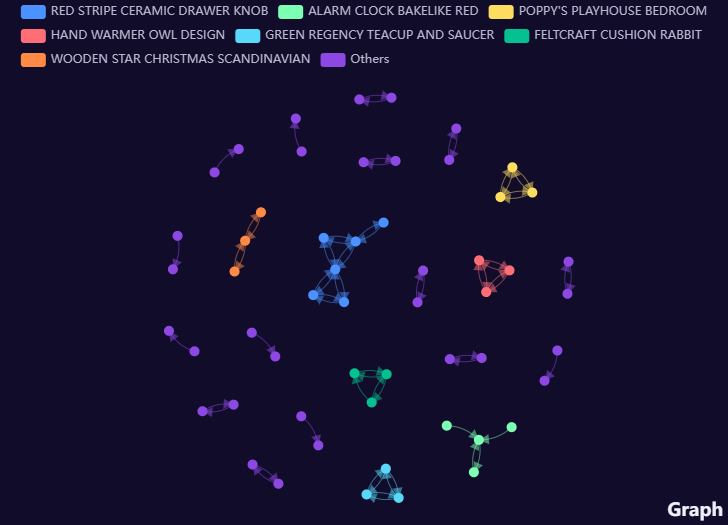

##  Product Placement with Plotly Heatmap

We can display our products side by side using Plotly heatmap

In [ ]:
MyHM = HeatmapCrosstab(rules)

In [ ]:
tabular = MyHM.get_tabular_data(
    ['WHITE HANGING HEART T-LIGHT HOLDER', 'RED HANGING HEART T-LIGHT HOLDER'], 
    'support',
    max_col=10
)

In [ ]:
fig_heatmap = MyHM.plot_heatmap(tabular)

In [ ]:
# fig_heatmap.show()

In [ ]:
# fig_heatmap.write_image("images/heatmap_xtab.png")

![Description](images/heatmap_xtab.png)

## Summary Report

### Top 5 Support

In [ ]:
rules.sort_values('support', ascending=False).iloc[::2].head(5).reset_index(drop=True)

### Bunde Products

In [ ]:
df_bundle_products.groupby('category').agg(
    products=('nodes', 'unique'), 
    support_mean=('support', 'mean'), 
    n=('nodes', 'size')
).sort_values('support_mean', ascending=False)

### Product Layout

In [ ]:
PRODUCTS_CATEGORY = "RED STRIPE CERAMIC DRAWER KNOB"
products_bundles = df_bundle_products[df_bundle_products['category'].str.contains(PRODUCTS_CATEGORY)]['nodes'].values

In [ ]:
tabular = MyHM.get_tabular_data(
    products_bundles, 
    'support',
    max_col=10,
    personal_placement=False
)

In [ ]:
MyHM.plot_heatmap(tabular)